In [153]:
from limited_data_experiment import (
    score_oracle,
    do_experiment,
    load_experiments_data_spe,
    make_pandas,
)
import numpy as np
from itertools import count
import multiprocessing as mp
from functools import partial
from matplotlib import pyplot as plt

# ALL_RUNS = [30, 31, 32, 33, 34]
ALL_RUNS = [100, 101, 102, 103, 104]

In [154]:
sim_data_random, perf_data_random, solver_selector = load_experiments_data_spe(
    runs=ALL_RUNS, random_selection=True
)

num_solvers = solver_selector.solver_space.all_decisions_encoding.shape[0]

df_sim, df_perf = make_pandas(
    sim_data=sim_data_random,
    perf_data=perf_data_random,
    seq_ids=ALL_RUNS,
)
X = np.stack(df_perf.features)
X = np.clip(X, -1e10, 1e10)
y = np.array(df_perf.reward)

In [211]:
y

array([-200.        ,   -0.6022142 , -200.        , ...,   -0.72895679,
         -1.02351217,   -1.07471036])

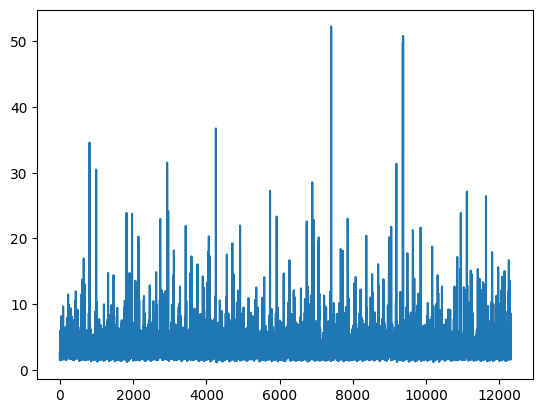

In [213]:
plt.plot(np.exp(-y[y > -4]))

In [214]:
np.exp(-y[y > -4]).mean()

3.075769362350103

(array([1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 1.000e+00, 1.000e+00,
        0.000e+00, 1.100e+01, 1.000e+01, 8.000e+00, 1.600e+01, 2.900e+01,
        2.400e+01, 2.300e+01, 1.100e+01, 5.000e+00, 0.000e+00, 1.200e+01,
        1.300e+01, 1.900e+01, 1.800e+01, 1.900e+01, 2.400e+01, 2.200e+01,
        8.000e+00, 4.000e+00, 4.000e+00, 3.000e+00, 2.000e+00, 6.000e+00,
        1.000e+00, 3.000e+00, 2.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 1.000e+00,
        2.000e+00, 2.000e+00, 2.000e+00, 2.000e+00, 7.000e+00, 7.000e+00,
        6.000e+00, 5.000e+00, 1.000e+01, 6.000e+00, 9.000e+00, 1.800e+01,
        1.400e+01, 2.800e+01, 2.300e+01, 2.700e+01, 4.400e+01, 3.300e+01,
        4.600e+01, 6.500e+01, 7.900e+01, 1.090e+02, 1.580e+02, 1.800e+02,
        2.290e+02, 2.470e+02, 2.660e+0

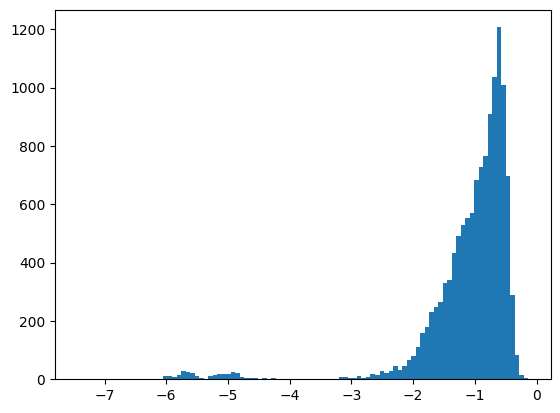

In [148]:
plt.hist(y[y > -100], bins=100)

In [200]:
y_by_solver_id = np.zeros(num_solvers)
count_solver_id = np.bincount(np.array(df_perf.decision_idx), minlength=num_solvers)
np.add.at(y_by_solver_id, np.array(df_perf.decision_idx), np.array(df_perf.reward))
success = (count_solver_id > 0) & (y_by_solver_id > -100)
y_by_solver_id[success] /= count_solver_id[success]

In [ ]:
sorted_idx = np.argsort(y_by_solver_id[success])[::-1]
sorted_idx

NameError: name 'np' is not defined

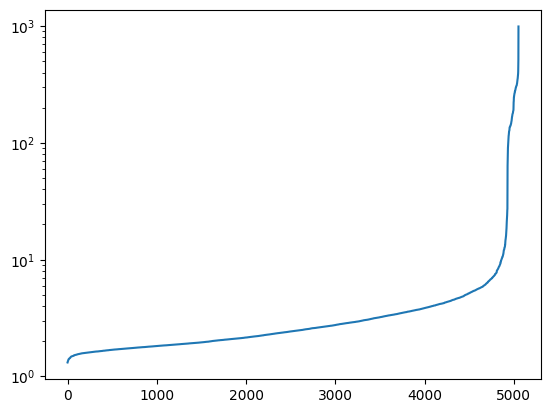

In [205]:
plt.plot(np.exp(-y_by_solver_id[success][sorted_idx]))
plt.yscale('log')

* consider methods that treat optimization problem: ((i) sort out bad methods (ii) try to find the best possible, assuming that you have a long tail)
1. deal with large number of solvers - scalable method with number of solvers
2. explore utility of having initial performance data
3. acknowledge that all sims are to some degree unique and there will be solution specific features. Natural to consider some sort of exploration. Worthwile?

Topics that we want to address. Plot of the sorted solver performance illustrates: we have the data set where you can do bad things.
If 3600-3900 and avg 3 are correct (?) - declare success on having solver selection alg.
nuances - 2nd order concern for this problem.
Going from 7500 to 4000 - good. We manage. How good we are below 4000 - 2nd order concern. 

In [1]:
3900 / 2500

1.56

(array([6.351e+03, 1.739e+03, 3.655e+03, 9.740e+02, 1.081e+03, 2.790e+02,
        2.420e+02, 5.600e+01, 2.400e+01, 7.000e+00, 4.000e+00, 2.000e+00,
        1.000e+00]),
 array([ 0.        ,  0.92307692,  1.84615385,  2.76923077,  3.69230769,
         4.61538462,  5.53846154,  6.46153846,  7.38461538,  8.30769231,
         9.23076923, 10.15384615, 11.07692308, 12.        ]),
 <BarContainer object of 13 artists>)

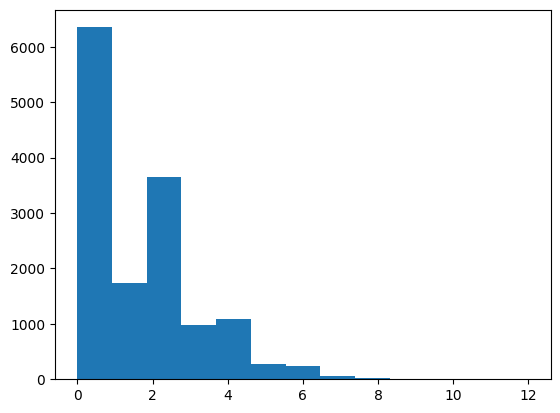

In [ ]:

decision_hist = np.zeros(num_solvers)
np.add.at(decision_hist, np.array(df_perf.decision_idx), 1)
plt.hist(decision_hist, bins=13)

In [117]:
cv_results, scoring = score_oracle(load_experiments_data_spe, ALL_RUNS, n_jobs=-1)

for score in scoring:
    print(score)
    print("Train scores:", cv_results[f"train_{score}"])
    print("Test scores:", cv_results[f"test_{score}"])
    print("Mean Train:", np.mean(cv_results[f"train_{score}"]))
    print("Mean Test:", np.mean(cv_results[f"test_{score}"]))
    print()

print('y mean', cv_results['y_mean'])
print('y std', cv_results['y_std'])
print('success_rate', cv_results['success_rate'])

Scoring oracle
mae_success
Train scores: [-0.11563307 -0.11773203 -0.11872395 -0.1186961  -0.11775388]
Test scores: [-0.11690049 -0.12060234 -0.11940595 -0.12234269 -0.12295639]
Mean Train: -0.1177078064601238
Mean Test: -0.1204415706094718

r2_success
Train scores: [0.95692887 0.95287379 0.95144098 0.95031597 0.95234191]
Test scores: [0.94793442 0.95167646 0.95163928 0.95203535 0.94147949]
Mean Train: 0.9527803043740143
Mean Test: 0.9489530007129586

acc_failure
Train scores: [0.9936438  0.9936438  0.99358087 0.9940847  0.99295199]
Test scores: [0.99144224 0.98741505 0.99169393 0.99446123 0.99118832]
Mean Train: 0.99358103163389
Mean Test: 0.991240153513558

f1_failure
Train scores: [0.99126222 0.99123644 0.99114891 0.99195619 0.99022005]
Test scores: [0.98815331 0.98281787 0.98866369 0.99204052 0.98823529]
Mean Train: 0.9911647609702362
Mean Test: 0.9879821368151722

y mean -1.0939984331622306
y std 0.8099211596279086
success_rate 0.3648995619996979


In [140]:
y_mean = cv_results['y_mean']
y_std = cv_results['y_std']
time_mean = np.exp(-y_mean)
time_std = time_mean * y_std
print(f'{y_mean = }, {y_std = }')
print(f'{time_mean = }, {time_std = }')

y_mean = -1.0939984331622306, y_std = 0.8099211596279086
time_mean = 2.9861903159238, time_std = 2.418578723542635


In [3]:
from limited_data_experiment import (
    do_experiment,
    load_experiments_data_spe,
)
from itertools import count
import multiprocessing as mp
from functools import partial

GAMMA_VALS = [
    0.005,
    0.01,
    0.05,
    0.1,
    # 0.5,
    # 1,
]
EPS_VALS = [
    0,
    0.1,
    0.5,
    0.9,
]

experiment_setups = []


for seq_id in ALL_RUNS:
    for gamma in GAMMA_VALS:
        for eps in EPS_VALS:
            experiment_setups.append(
                {
                    "incremental_learning": True,
                    "one_decision": False,
                    "seq_id": seq_id,
                    "gamma": gamma,
                    'gamma1': 0.1,
                    "eps": eps,
                    "batch_size": 128,
                }
            )

    # for one_decision in [False, True]:
    #     experiment_setups.append(
    #         {
    #             "incremental_learning": False,
    #             "one_decision": one_decision,
    #             "seq_id": seq_id,
    #             "gamma": 1,
    #             "eps": 0,
    #             "batch_size": 128,
    #         }
    #     )

cnt = count()
for experiment in experiment_setups:
    experiment["experiment_idx"] = next(cnt)
    experiment["experiments_total"] = len(experiment_setups)

num_processes = mp.cpu_count()
print(f"{num_processes = }")
with mp.Pool(num_processes) as pool:
    results = pool.map(partial(do_experiment, load_experiments_data=partial(load_experiments_data_spe, dir="../stats/"), all_run_ids=ALL_RUNS), experiment_setups)


# results = [do_experiment(x, load_experiments_data=partial(load_experiments_data_spe, dir="../stats/")) for x in experiment_setups]

num_processes = 16


Start experiment 18 / 80Start experiment 10 / 80

Start experiment 16 / 80Start experiment 8 / 80

Start experiment 14 / 80
Start experiment 12 / 80
Start experiment 28 / 80
Start experiment 22 / 80
Start experiment 2 / 80Start experiment 0 / 80

Start experiment 20 / 80
Start experiment 4 / 80
Start experiment 30 / 80
Start experiment 26 / 80
Start experiment 24 / 80
Start experiment 6 / 80
Done experiment 22 / 80
Done experiment 20 / 80
Start experiment 23 / 80
Start experiment 21 / 80
Done experiment 18 / 80
Done experiment 16 / 80
Start experiment 19 / 80
Start experiment 17 / 80
Done experiment 30 / 80
Done experiment 14 / 80
Done experiment 0 / 80
Start experiment 31 / 80
Start experiment 15 / 80
Start experiment 1 / 80
Done experiment 4 / 80
Done experiment 8 / 80
Done experiment 24 / 80
Start experiment 5 / 80
Start experiment 9 / 80
Done experiment 26 / 80
Start experiment 25 / 80
Start experiment 27 / 80
Done experiment 10 / 80
Done experiment 6 / 80
Start experiment 11 / 80


data points: 3961

num solvers: ~16k

In [ ]:
# results = [do_experiment(x, load_experiments_data=partial(load_experiments_data_spe, dir="../stats/"), all_run_ids=ALL_RUNS) for x in experiment_setups]

In [4]:
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib

matplotlib.rcdefaults()

# tex_fonts = {
#     # Use LaTeX to write all text
#     # "text.usetex": True,
#     "font.family": "serif",
#     "axes.labelsize": 10,
#     "font.size": 10,
#     # Make the legend/label fonts a little smaller
#     "legend.fontsize": 9,
#     "xtick.labelsize": 9,
#     "ytick.labelsize": 9,
# }

# sns.set_theme(
#     # context="talk",
#     context="paper",
#     # rc={"figure.figsize": (8, 6)},
#     # palette="colorblind6",
#     style="whitegrid",
#     rc=tex_fonts,
# )

In [112]:
from collections import defaultdict
import numpy as np
import pandas as pd


data_for_pandas = defaultdict(lambda: [])
for result in results:
    data_for_pandas["incremental_learning"].append(result["incremental_learning"])
    data_for_pandas["one_decision"].append(result["one_decision"])
    data_for_pandas["seq_id"].append(result["seq_id"])
    data_for_pandas["gamma"].append(result["gamma"])
    data_for_pandas["eps"].append(result["eps"])
    data_for_pandas["batch_size"].append(result["batch_size"])
    data_for_pandas["NTS"].append((result["NTS"]))
    data_for_pandas["TopEPS"].append((result["TopEPS"]))
    data_for_pandas["mean_NTS"].append(np.mean(result["NTS"]))
    data_for_pandas["mean_TopEPS"].append(np.mean(result["TopEPS"]))
    data_for_pandas['ypred'].append(result['ypred'])
    data_for_pandas['yoracle'].append(result['yoracle'])
    data_for_pandas['yfeedback'].append(result['yfeedback'])
    data_for_pandas['tpred'].append(result['tpred'])
    data_for_pandas['tfeedback'].append(result['tfeedback'])
    data_for_pandas['decision_id'].append(result['decision_id'])

    tmp = result['yfeedback']
    
    data_for_pandas['time_feedback'].append(np.sum(np.exp(-tmp[tmp > -100])))


df = pd.DataFrame(data_for_pandas)

df.head(1)

,incremental_learning,one_decision,seq_id,gamma,eps,batch_size,NTS,TopEPS,mean_NTS,mean_TopEPS,ypred,yoracle,yfeedback,tpred,tfeedback,decision_id,time_feedback
0,True,False,100,0.005,0.0,128,"[0.9459439001430314, 0.9462105086092252, 0.946...","[False, False, False, False, False, False, Fal...",0.991242,0.852778,"[-0.16881321596910617, -0.16881321596910617, -...","[-0.23742944537344463, -0.24668406848426497, -...","[-0.36896893121135665, -0.378223554322177, -0....","[0.02220320701599121, 0.022083282470703125, 0....","[4.291534423828125e-06, 4.0531158447265625e-06...","[8922, 8922, 8922, 8922, 8922, 8922, 8922, 892...",3539.244943


In [113]:
df_heatmap = df[(df.incremental_learning) & ~(df.one_decision)]
# df_heatmap = df_heatmap.groupby(["eps", 'gamma'])["mean_TopEPS"].agg(["mean", 'std']).unstack()
# df_heatmap = df_heatmap.groupby(["eps", 'gamma'])["mean_NTS"].agg(["mean", 'std']).unstack()
df_heatmap = df_heatmap.groupby(["eps", 'gamma'])["time_feedback"].agg(["mean", 'std']).unstack()


df_heatmap

mean                                                std  \
gamma        0.005        0.010        0.050        0.100       0.005   
eps                                                                     
0.0    3600.463272  3613.910775  3505.315095  3507.785443   98.164721   
0.1    3719.513795  3744.751408  3652.716232  3657.419982   90.862245   
0.5    3788.225177  3757.680518  3660.360587  3666.110365  107.765629   
0.9    3918.744725  3890.915139  3885.267326  3812.536755   84.764246   

                                         
gamma      0.010       0.050      0.100  
eps                                      
0.0    35.608895   31.743544  26.922897  
0.1    73.523378   43.473108  36.062616  
0.5    65.625524   43.508681  33.520723  
0.9    89.911227  176.744749  40.322334

In [114]:
annot = df_heatmap['mean'].round(0).astype(str) + "±" + df_heatmap['std'].round(0).astype(str)
annot

gamma,0.005,0.010,0.050,0.100
eps,,,,
0.0,3600.0±98.0,3614.0±36.0,3505.0±32.0,3508.0±27.0
0.1,3720.0±91.0,3745.0±74.0,3653.0±43.0,3657.0±36.0
0.5,3788.0±108.0,3758.0±66.0,3660.0±44.0,3666.0±34.0
0.9,3919.0±85.0,3891.0±90.0,3885.0±177.0,3813.0±40.0


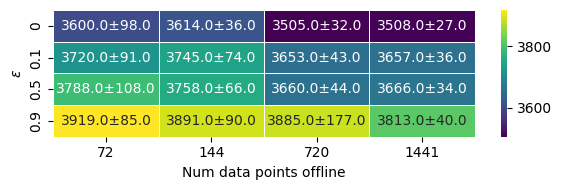

In [135]:
plt.figure(figsize=(6, 2))
sns.heatmap(
    np.array(df_heatmap["mean"]),
    # np.array(df_heatmap["std"]),
    annot=np.array(annot),
    cmap="viridis",
    linecolor="white",
    linewidths=0.5,
    yticklabels=EPS_VALS,
    xticklabels=(np.array(GAMMA_VALS) * num_solvers).astype(int),
    fmt="",
)
plt.ylabel(r"$\varepsilon$")
# plt.xlabel(r"$\gamma$")
plt.xlabel('Num data points offline')
# plt.title(r"Top-$\varepsilon$ Acc.", fontweight="bold")
plt.tight_layout()
# plt.savefig("scenarioA_topeps.pdf")

axes: solver id (sorted by avg reward) vs avg reward

In [143]:
2500 * time_mean

7465.4757898095

In [144]:
(1441 - 720 ) * time_mean

2153.04321778106

In [139]:
time_mean, time_std

(2.9861903159238, 2.418578723542635)

* plot y data

In [138]:
(1441 - 720) * (time_mean - time_std)

409.2479581068202

* absolute value score (seconds)
* average baseline solver - cost of moving f1rom 0.01 to 0.05

In [ ]:
from sklearn.neural_network import MLPRegressor

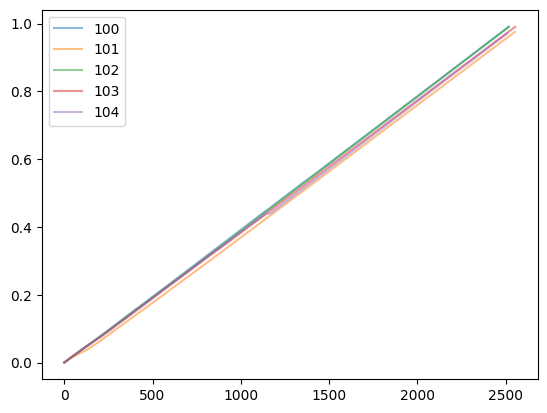

In [15]:
from matplotlib import pyplot as plt

for row in df[(df.eps == 0.) & (df.gamma == 0.005) & (df.incremental_learning) & ~df.one_decision].itertuples(index=False):
    # plt.plot((row.NTS), label=row.seq_id, alpha=0.5)

    # plt.plot(np.cumsum(row.TopEPS) / np.size(row.TopEPS), label=row.seq_id, alpha=0.5)
    plt.plot(np.cumsum(row.NTS) / np.size(row.NTS), label=row.seq_id, alpha=0.5)

plt.legend()


In [16]:
df_special = df[~df.incremental_learning]
df_special = df_special.groupby('one_decision')[['mean_NTS']].agg(["mean", 'std'])
df_special

Empty DataFrame
Columns: [(mean_NTS, mean), (mean_NTS, std)]
Index: []

In [17]:
df_special['mean_NTS']

,mean,std
one_decision,,


/tmp/ipykernel_2691038/3740096419.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


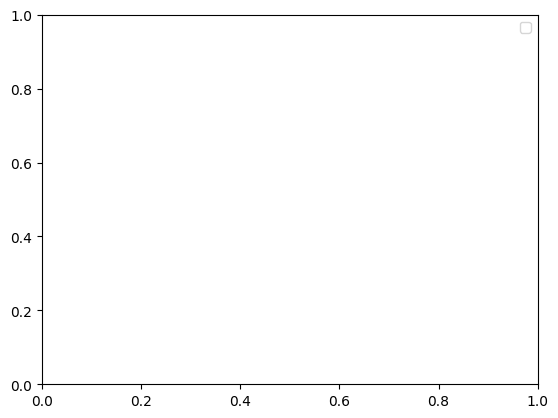

In [18]:
from matplotlib import pyplot as plt

for row in df[(df.eps == 0.5) & (df.seq_id == 'R34') & (df.incremental_learning) & ~df.one_decision].itertuples(index=False):
    plt.plot(np.cumsum(row.TopEPS) / np.size(row.TopEPS), label=row.gamma, alpha=0.5)
    # plt.plot(np.cumsum(row.NTS) / np.size(row.NTS), label=row.gamma, alpha=0.5)

plt.legend()

Text(0, 0.5, 'ML overhead, s')

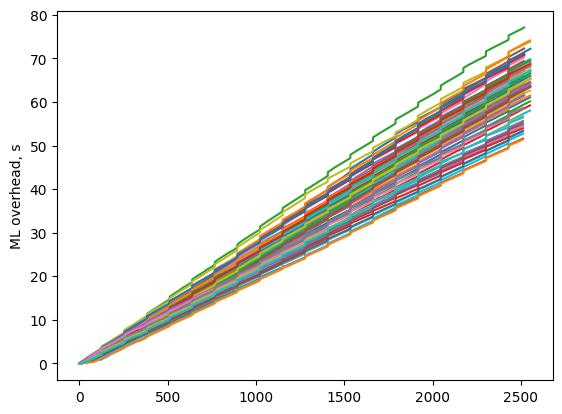

In [19]:
for row in df.itertuples(index=False):
    plt.plot(np.cumsum(row.tfeedback + row.tpred))

plt.ylabel('ML overhead, s')

In [30]:
row.yoracle.min()

-100.0

Text(0, 0.5, 'Run time, s')

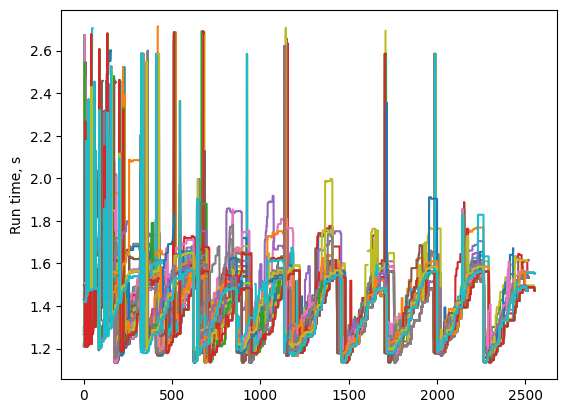

In [206]:
for row in df.itertuples(index=False):
    tmp = np.array(row.yfeedback)
    tmp[tmp <= -1] = np.nan
    plt.plot(np.array(np.exp(-tmp)))

plt.ylabel('Run time, s')

In [34]:
tmp.min()

-100.0